In [2]:
import matplotlib.pyplot as plt
import numpy as np
import openmm
from openmm import unit
from openmm import CustomExternalForce

%matplotlib inline

In [3]:
radius1 = 105.0
radius2 = 85.0
sigma_avg = (radius1 + radius2)/2

brush_length = 10.0
brush2=2*brush_length

brush_density=0.09

h_vals = np.linspace(15.0, 36.0, num=1000)

#phi = #volume fraction of depletants
#rcc = #center-to-center distance
#rdep #radius of the polymer depletant

In [4]:
def expected_brush_repulsion(steric_prefactor, h):
        """
        Return the steric potential from the Alexander-de Gennes polymer brush model for the given 
        surface-to-surface separations.
        """
        brush2 = 2.0 * brush_length
        
        return (steric_prefactor * np.where(h <= brush2,
                                     28.0 * (np.power(brush2 / h, 0.25) - 1.0)
                                     + 20.0 / 11.0 * (1.0 - np.power(h / brush2, 2.75))
                                     + 12.0 * (h / brush2 - 1.0),
                                     0.0) )#,
               # -steric_prefactor / brush2 * np.where(h_values <= brush2,
                #                                            -7.0 * np.power(double_brush_length_over_h, 1.25)
                 #                                           - 5.0 * np.power(h_over_double_brush_length, 1.75)
                  #                                          + 12.0, 0.0))


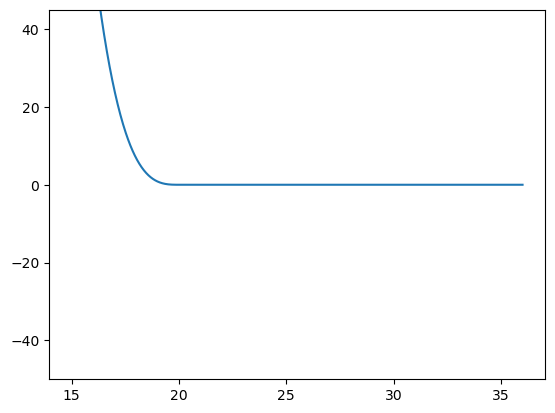

In [39]:
steric_prefactor = 16*np.pi*sigma_avg*(brush2**2)*(brush_density**(3./2))/35.
potential_vals = expected_brush_repulsion(steric_prefactor, h_vals)
plt.plot(h_vals, potential_vals)
plt.ylim(-50, 45)
plt.show()

In [26]:
def expected_AO_potential(h, radius1, radius2, brush_length, phi, rdep):
    """
    Return the Asakura-Oosawa potential (generalized to asymmetric sphere) for a colloidal solution in a 
    background of non-adsorbing polymers.

    radius1: radius of first type of colloidal particle
    radius2: radius of second type of colloidal particle
    brush_length: length of polymer brush
    phi: volume fraction of polymer depletants
    rdep: radius of polymer depletants
    rcc: center-to-center separation distance  
    h: surface-to-surface particle separation distance 
    """
    
    sigmaD1 = brush_length + radius1 
    sigmaD2 = brush_length + radius2
    rcc = h + radius1 + radius2
    #h = rcc - radius1 - radius2 #surface to surface distance
    q1 = sigmaD1/rdep 
    q2 = sigmaD2/rdep
    n = rcc/rdep
    #sigma_avg = 2/(1/radius1+1/radius2)
    sigma_avg = (radius1 + radius2)/2
    
    if rcc <= (sigmaD1 + sigmaD2 + 2*rdep):

        AO_potential = -phi/16*(q1+q2+2-n)**2*(n+2*(q1+q2+2)-3/n*(q1**2+q2**2-2*q1*q2))
    
    else:
        
        AO_potential = 0 
        
    return AO_potential 
    

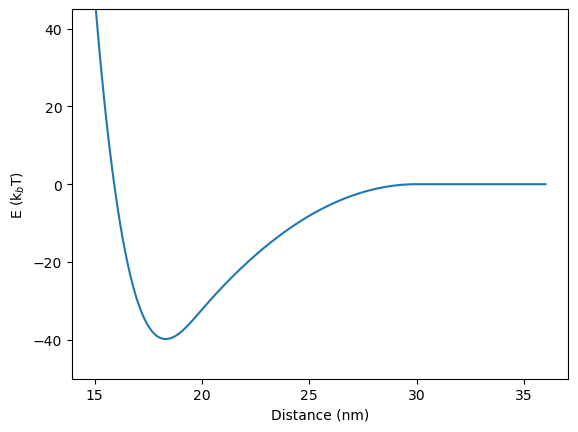

In [50]:
h_vals = np.linspace(15.0, 36.0, num=1000)


ao_vals = []

for h in h_vals:
    
    ao = expected_AO_potential(h, radius1, radius2, brush_length, 1, 5)

    ao_vals.append(ao)
    
#plt.plot(h_vals, ao_vals)
#plt.plot(h_vals, potential_vals)
plt.plot(h_vals, potential_vals+ ao_vals)
plt.xlabel('Distance (nm)')
plt.ylabel('E (k$_b$T)')
plt.ylim(-50, 45)
plt.show()